# ECE 227 Project

## Topic: 1 Network Analysis and Visualization using NetworkX and Gephi

## Group Members
- Jiayi Chen | A17496530 | jic101@ucsd.edu
- Junyi Wu | A17034047 | juw040@ucsd.edu
- Matthew Alegrado | A16752818 | malegrado@ucsd.edu
- Qinpei Luo | A69035113 | qpluo@ucsd.edu
- Zihao Yang | A16751774 | ziy019@ucsd.edu

## 1. Network Preparation

We download the following models:  
1. Collaboration: [GR-QC (General Relativity and Quantum Cosmology) collaboration network](https://snap.stanford.edu/data/ca-GrQc.html). 
2. Enron email network [Enron email network](https://snap.stanford.edu/data/email-Enron.html).  
3. Social circles: Facebook [Social circles: Facebook](https://snap.stanford.edu/data/ego-Facebook.html)

In [1]:
import networkx as nx
G = nx.read_edgelist("models/facebook_combined.txt")
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of nodes: 4039
Number of edges: 88234


## Degree Distribution Analysis

In [2]:
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import powerlaw
from pathlib import Path
import networkx as nx
from itertools import combinations

class DegreeAnalysis:
    fit_empty = {
            'in': {'fit': None, 'degrees': None},
            'out': {'fit': None, 'degrees': None},
            'undirected': {'fit': None, 'degrees': None}
                   }
    reciprocity_threshold = 0.98
    def __init__(self, models_path, directed_map=None):
        """
        models_path: folder containing all .txt model files.
        directed_map: dict {filename_stem: True/False}
        """
        assert isinstance(models_path, Path)

        if directed_map is None:
            directed_map = {}

        graphs = {}

        for file in models_path.glob("*.txt"):
            name = file.stem
            is_directed = directed_map.get(name, True)  # default True if not specified

            if is_directed:
                G = nx.read_edgelist(
                    str(file),
                    nodetype=int,
                    create_using=nx.DiGraph(),
                    data=False
                )
            else:
                G = nx.read_edgelist(
                    str(file),
                    nodetype=int,
                    create_using=nx.Graph(),
                    data=False
                )

            graphs[name] = G

        print("Loaded graphs:",
              [(name, "Directed" if G.is_directed() else "Undirected")
               for name, G in graphs.items()])

        self.graphs = graphs
        self.fit = self.fit_empty.copy()

    def node_degree_distribution(self, G, **kwargs):
        """
        Retrieve node degree distribution from graph as normalized vector of `P(node degree) = k` values.
        """
        degrees = self.get_degrees(G)
        output = []
        for i, deg in enumerate(degrees):
            hist = np.bincount(deg)
            p_k = hist / len(deg)
            k = np.arange(len(hist))
            output.append((hist, p_k, k))
    
        return output
    
    def plot_degree_distribution(self, p_k, deg, loglog=False, plotname=None, in_deg=None, **kwargs):
        """
        Plot degree distribution on either a linear or loglog scale. Select loglog to detect scale free properties.
        """
        assert isinstance(p_k, np.ndarray), type(p_k)
        assert isinstance(deg, list) or isinstance(deg, np.ndarray), f'deg type: {type(deg)}'
        assert isinstance(loglog, bool)
        assert plotname is not None, 'need plot name'

        if in_deg is None:
            prepend = ''
        elif in_deg:
            prepend = 'In-degree '
        else:
            prepend = 'Out-degree '
    
        if loglog:
            mask = (np.array(deg) > 0) & (p_k > 0)
            plt.scatter(np.array(deg)[mask], p_k[mask])
            plt.xscale('log')
            plt.yscale('log')
            plt.xlabel("log(Degree k)")
            plt.ylabel("log P(k)")
            plt.title(prepend + f"Log-Log Degree Distribution for {plotname}")
        else:
            plt.scatter(deg, p_k)
            plt.xlabel("Degree k")
            plt.ylabel("P(k)")
            plt.title(prepend + f"Degree Distribution for {plotname}")
        plt.show()
    
    def fit_equation(self, G, in_deg=None, **kwargs):
        """
        Fit a power law and other common model distributions to the given data and determine the best one using MLE.
        If R > 0, power law is more likely than alternative, and vice versa. For p < 0.05, this result is statistically significant.
        
        # Returns the best model(s) as a list of strings representing the distribution names. 
        """
        degrees = self.get_degrees(G)
        if in_deg is None or in_deg:
            degrees = degrees[0]
        else:
            degrees = degrees[1]

        fit = self.get_fit(degrees, in_deg=in_deg)
            
        print(f"alpha (power law exponent): {fit.power_law.alpha:.4f}")
        print("k_min (minimum value of k before power law kicks in):", int(fit.power_law.xmin))
        print()
        
        results = {}
        dists = fit.supported_distributions

        # Round 1: compare against power law
        winning_dists = []
    
        for dist in dists:
            if dist != 'power_law':
                R, p = fit.distribution_compare('power_law', dist)
                results[dist] = (R, p)

        for dist, (R, p) in results.items():
            if R < 0 and p < .05:
                winning_dists.append(dist)
        if len(winning_dists) > 0:
            print('Distributions better than power-law:', winning_dists)
        else:
            return ['power_law']

        # Round 2: compare distributions that won against power law, n choose 2   
        scores = {d: 0 for d in winning_dists}
        for d1, d2 in combinations(winning_dists, 2):
            R, p = fit.distribution_compare(d1, d2)
            if p < .05:
                if R > 0:
                    scores[d1] += 1
                else:
                    scores[d2] += 1
        print('Scores from pairwise distribution comparison:', scores)

        best_models = []
        best_scores = []
        for dist, score in scores.items():
            if score == max(scores.values()):  # Add models that won most, or all if they all tied
                best_models.append(dist)
                best_scores.append(score)

        assert len(best_models) > 0, f'best models is empty! '
        return best_models, best_scores

    def giant_component(self, G):
        connected_components = nx.weakly_connected_components if G.is_directed() else nx.connected_components
        gc_nodes = max(connected_components(G), key=len)
        return G.subgraph(gc_nodes).copy()

    def get_diameter(self, G):
        is_connected = nx.is_weakly_connected if G.is_directed() else nx.is_connected
        if is_connected(G):
            diameter = nx.algorithms.approximation.diameter(G)
        else:
            gc = self.giant_component(G)
            diameter = nx.algorithms.approximation.diameter(gc)
        return diameter    

    def get_avg_shortest_path(self, G):
        is_connected = nx.is_weakly_connected if G.is_directed() else nx.is_connected
        if is_connected(G):
            shortest_path = nx.average_shortest_path_length(G)
        else:
            gc = self.giant_component(G)
            shortest_path = nx.average_shortest_path_length(gc)
        return shortest_path

    def analyze_distances(self, G, name=''):
        diameter = self.get_diameter(G)
        shortest_path = self.get_avg_shortest_path(G)
        is_connected = nx.is_weakly_connected if G.is_directed() else nx.is_connected
        if G.is_directed():
            print(name + ' ' + f'Approximate diameter: {diameter}, Avg. Shortest Path: {shortest_path:.3f}, Is connected? {is_connected(G)}, Reciprocity: {nx.reciprocity(G):.4f}')
        else:
            print(name + ' ' + f'Approximate diameter: {diameter}, Avg. Shortest Path: {shortest_path:.3f}, Is connected? {is_connected(G)}')

    def run_analysis(self, **kwargs):
        """
        Main function for DegreeAnalysis. 
        Analyzes all loaded networks: degree distributions, diameter, shortest path, and maximum likelihood network model.
        """
        for name, G in self.graphs.items():
            self.fit = self.fit_empty.copy()
            print(f'\n-----  Analyzing {name} network...  -----\n')

            self.analyze_distances(G, name=f'({name}) (Empirical)')
            
            output = self.node_degree_distribution(G, **kwargs)
            if len(output) == 2 and nx.reciprocity(G) < self.reciprocity_threshold:
                in_deg = True
                for hist, p_k, k in output:
                    self.plot_degree_distribution(p_k, k, plotname=name, in_deg=in_deg, **kwargs)
                    best_models_scores = self.fit_equation(G, in_deg=in_deg, **kwargs)
                    degrees = self.get_degrees(G)
                    self.simulate_model(best_models_scores, degrees, dataset_name=name, **kwargs)
                    in_deg = False
            elif len(output) == 2:
                print(f'Simplifying directed graph to undirected, since its reciprocity is above threshold {self.reciprocity_threshold}')
                in_deg = None
                G = G.to_undirected()
                hist, p_k, k = output[0]
                self.plot_degree_distribution(p_k, k, plotname=name, in_deg=in_deg, **kwargs)
                best_models_scores = self.fit_equation(G, in_deg=in_deg, **kwargs)
                degrees = self.get_degrees(G)
                self.simulate_model(best_models_scores, degrees, dataset_name=name, **kwargs)
            else:
                in_deg = None
                hist, p_k, k = output[0]
                self.plot_degree_distribution(p_k, k, plotname=name, in_deg=in_deg, **kwargs)
                best_models_scores = self.fit_equation(G, in_deg=in_deg, **kwargs)
                degrees = self.get_degrees(G)
                self.simulate_model(best_models_scores, degrees, dataset_name=name, **kwargs)
            

    def simulate_model(self, models_scores, degrees, dataset_name='', **kwargs):
        """
        Run a simulation given some model distribution and plot against the real data.
        """
        for item in models_scores:
            assert isinstance(item, list), 'need list of models and their scores, even if len 1'
        models = models_scores[0]
        scores = models_scores[1]
        assert len(models) == len(scores), 'lengths do not match between models and scores'
        m = len(models)
        assert m > 0, 'model list empty'

        for i, k in enumerate(degrees):  # In-degree and out-degree, in that order, for directed. Undirected is length 1.
            in_deg = True if i == 0 else False
            if i == 0 and len(degrees) == 2:
                in_deg = True
                print('Looking at in-degrees...')
            elif i == 1:
                in_deg = False
                print('Looking at out-degrees...')
            else:
                in_deg = None
                
            fit = self.get_fit(k, in_deg=in_deg)
            
            ncols = int(np.ceil(np.sqrt(m)))
            nrows = int(np.ceil(m / ncols))
        
            fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), squeeze=False)
            axes = axes.ravel()
        
            for idx, model_name in enumerate(models):
                ax = axes[idx]
        
                dist = getattr(fit, model_name)
                sim = dist.generate_random(len(k))
        
                fit.plot_ccdf(ax=ax, label="Empirical")
                fit.power_law.plot_ccdf(ax=ax, label="Fit: power_law")
                # getattr(fit, model_name).plot_ccdf(label=f"Theoretical: {model_name}")
                self.plot_empirical_ccdf(sim, ax, label=f"Simulated: {model_name}")
                G_sim = self.sim_to_graph(sim)
                name = f'({dataset_name}) ({model_name})'
                self.analyze_distances(G_sim, name=name)

                if i == 0 and len(degrees) > 1:
                    ax.set_title(f"In-degree CCDFs: {model_name}")
                elif i == 1 and len(degrees) > 1:
                    ax.set_title(f"Out-degree CCDFs: {model_name}")
                else:
                    ax.set_title(f"CCDFs: {model_name}")
                ax.set_xlabel("k")
                ax.set_ylabel("P(K ≥ k)")
                ax.legend()
        
            for j in range(m, len(axes)):
                axes[j].axis("off")
    
            fig.tight_layout(rect=[0, 0, 1, 0.93])
            fig.suptitle(dataset_name)
            plt.show()

    def plot_empirical_ccdf(self, data, ax, label):
        """
        Plot complement CDF (survival function) of data on a given Axes object.
        """
        # data = np.sort(data)
        # n = len(data)
        # ccdf = 1 - np.arange(1, n+1) / n
        # ax.loglog(data, ccdf, marker='.', linestyle='--', label=label)
        x, counts = np.unique(data, return_counts=True)
        ccdf = 1 - np.cumsum(counts) / counts.sum()
        ax.loglog(x, ccdf, marker='.', linestyle='--', label=label)

    def get_fit(self, degrees, in_deg=None):
        if in_deg is not None:
            assert isinstance(in_deg, bool)

        if in_deg is None:
            key = 'undirected'
        elif in_deg:
            key = 'in'
        else:
            key = 'out'
            
        if self.fit[key]['degrees'] is not None:
            matching_degrees = self.key(self.fit[key]['degrees']) == self.key(degrees)
        if self.fit[key]['fit'] is None or not matching_degrees:
            fit = powerlaw.Fit(degrees, discrete=True)
            self.fit[key]['fit'] = fit
            self.fit[key]['degrees'] = degrees
        else:
            fit = self.fit[key]['fit']

        return fit

    def key(self, obj):
        obj = np.asarray(obj, dtype=np.int64)
        return hash(obj.tobytes())

    def get_degrees(self, G):
        if G.is_directed():
            in_degrees = np.array([d for _, d in G.in_degree()])
            out_degrees = np.array([d for _, d in G.out_degree()])
            return [in_degrees, out_degrees]
        else:
            degrees = np.array([d for _, d in G.degree()])
            return [degrees]

    def sim_to_graph(self, sim):
        deg = np.asarray(sim, dtype=int)
        if deg.sum() % 2 == 1:
            deg[np.argmax(deg)] += 1
        
        Gm = nx.configuration_model(deg, seed=42)
        G = nx.Graph(Gm)
        G.remove_edges_from(nx.selfloop_edges(G))
        return G

In [3]:
directed_map = {
    "CA-GrQc": True,
    "Email-Enron": True,
    "facebook_combined": False
}
graph_analyzer = DegreeAnalysis(Path('models'), directed_map)

Loaded graphs: [('CA-GrQc', 'Directed'), ('Email-Enron', 'Directed'), ('facebook_combined', 'Undirected')]



-----  Analyzing CA-GrQc network...  -----

(CA-GrQc) (Empirical) Approximate diameter: 17, Avg. Shortest Path: 6.049, Is connected? False, Reciprocity: 0.9996
Collapsing directed graph to undirected, since its reciprocity is above threshold 0.98


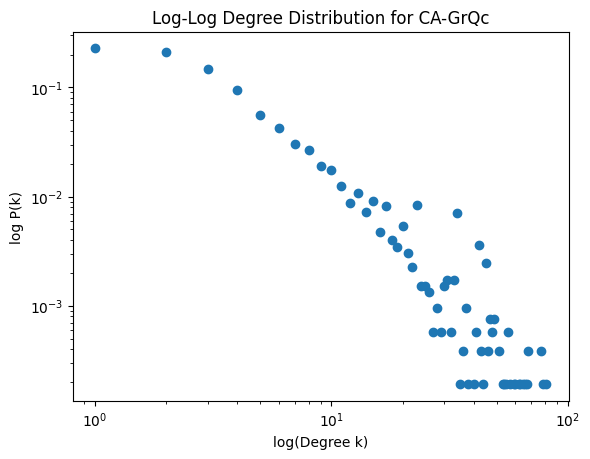

Calculating best minimal value for power law fit


Fitting xmin: 100%|████████████████████████████████████████████████████████████████████| 63/63 [00:00<00:00, 441.54it/s]

alpha (power law exponent): 2.1131
k_min (minimum value of k before power law kicks in): 3



Distributions better than power-law: ['lognormal', 'truncated_power_law', 'stretched_exponential', 'lognormal_positive']
Scores from pairwise distribution comparison: {'lognormal': 0, 'truncated_power_law': 3, 'stretched_exponential': 2, 'lognormal_positive': 0}
(CA-GrQc) (truncated_power_law) Approximate diameter: 6, Avg. Shortest Path: 3.680, Is connected? True


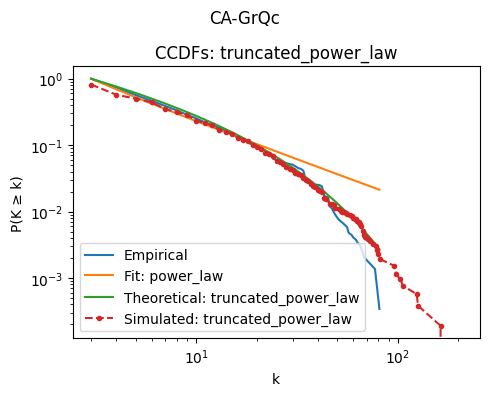


-----  Analyzing Email-Enron network...  -----



In [ ]:
graph_analyzer.run_analysis(loglog=True)